take input a , b, c from user
show the quadratic equation 
the based on condition find out the roots


In [61]:
from langgraph.graph import StateGraph , START,END
from typing import TypedDict , Literal


In [62]:
class QuadraticState(TypedDict):
    a:int
    b:int
    c:int
    d:float
    equation:str
    roots:float
    result:str

In [63]:
def show_equation(state:QuadraticState)->QuadraticState:
    a=state['a']
    b=state['b']
    c=state['c']
    equation=f'{a}x**2{b}x{c}'
    return {"equation":equation}

def calculate_discriminant(state:QuadraticState)->QuadraticState:
    a=state['a']
    b=state['b']
    c=state['c']
    d=b**2-(4*a*c)
    return {"d":d}

def real_roots(state:QuadraticState)->QuadraticState:
    root1=(-state['b']+state['d']**0.5)/(2*state['a'])
    root2=(-state['b']-state['d']**0.5)/(2*state['a'])
    result=f'both roots are respectively: {root1} and {root2}'
    return {"result":result}

def No_Realroots(state:QuadraticState)->QuadraticState:
    d=state['d']
    result=f'since d  is less than zero {d},So no real roots can be found.'
    return {"result":result}

def one_repeatative_roots(state:QuadraticState)->QuadraticState:
    root1=(-state['b'])/(2*state['a'])
    root2=(-state['b'])/(2*state['a'])
    result=f'both roots are equal and value is: {root1}'
    return {"result":result}

#   create a condition --> for which node should be exeucted based on a quadratic equation d value
def check_condition(state:QuadraticState)->Literal["real_roots","No_Realroots","one_repeatative_roots"]:
    if state["d"]>0:
        return "real_roots"
    elif state['d']==0:
        return "one_repeatative_roots"
    else:
        return "No_Realroots"

In [64]:
graph=StateGraph(QuadraticState)

graph.add_node("show_equation",show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)

graph.add_node("real_roots",real_roots)
graph.add_node("No_Realroots",No_Realroots)
graph.add_node("one_repeatative_roots",one_repeatative_roots)

graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant",check_condition)

graph.add_edge("real_roots",END)
graph.add_edge("No_Realroots",END)
graph.add_edge("one_repeatative_roots",END)


In [65]:
workflow=graph.compile()

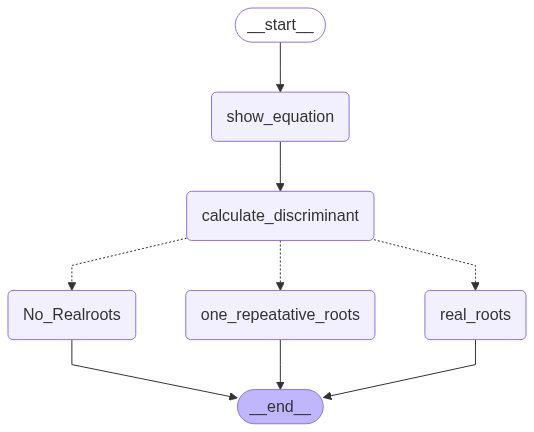

In [67]:
workflow

In [66]:
initial_state={"a":4,"b":-5,"c":-4}
final_state=workflow.invoke(initial_state)
print(final_state)


{'a': 4, 'b': -5, 'c': -4, 'd': 89, 'equation': '4x**2-5x-4', 'result': 'both roots are respectively: 1.8042476415070754 and -0.5542476415070754'}
